# Aircraft classification

In [3]:
import os
import math
import random
from pathlib import Path
from typing import List,Tuple

# import gdown
from PIL import Image
import matplotlib.pyplot as plt
# import seaborn as sns

import torch
from torch import Tensor
import torch.nn as nn
import  torch.nn.functional as F
from torch.optim import SGD,Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as datasets


import torchvision
from torchvision import transforms, models
from torchvision.transforms import RandAugment

In [3]:
from google.colab import drive
drive.mount('/content/drive')

print(os.path.exists('/content/drive/MyDrive'))
print("drive exists:", os.path.exists('/content/drive'))
print("MyDrive exists:", os.path.exists('/content/drive/MyDrive'))
drive_checkpoint_dir = '/content/drive/MyDrive/Aircaft classification/checkpoints'
cnn_weights_folder = drive_checkpoint_dir
local_data = '/content/data_aircraft'

os.makedirs(drive_checkpoint_dir, exist_ok=True)
# Checkpoint path
cnn_checkpoint1 = Path(drive_checkpoint_dir) / "cnn_checkpoint1.pt"



Mounted at /content/drive
True
drive exists: True
MyDrive exists: True


# Getting data

Mounted at /content/drive
Dataset incomplete or missing, re-download!


100%|██████████| 2.75G/2.75G [02:18<00:00, 19.9MB/s]


Training samples: 3334
Test samples: 3333
Classes: 100

Analysis of the first sample:
 - Dimension of the image tensor: torch.Size([3, 224, 224]) (Channels, Heigth, Length)
 - Index of the label: 0
 - Name of the variant: 707-320


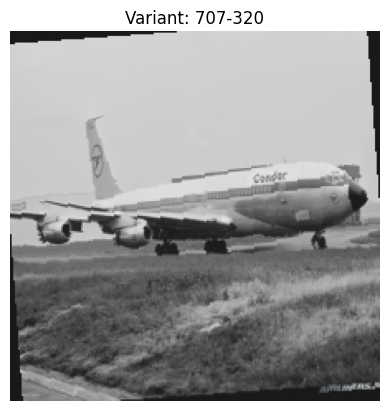

In [4]:
from google.colab import drive
import shutil, os

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Training transforms for Phase 1
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

drive.mount('/content/drive', force_remount=True)

drive_data = '/content/drive/MyDrive/Colab Notebooks/data_aircraft'
local_data = '/content/data_aircraft'

#
data_dir = local_data
# Checks dataset is complete
variants_exists = os.path.exists(os.path.join(data_dir, 'fgvc-aircraft-2013b/data/variants.txt'))

if variants_exists:
    print("Dataset complete, skip download!")
    download_flag = False
else:
    print("Dataset incomplete or missing, re-download!")
    if os.path.exists(data_dir):
        shutil.rmtree(data_dir)
    download_flag = True

# Train
train_dataset = datasets.FGVCAircraft(
    root=data_dir,
    split='train',
    annotation_level='variant',
    download=download_flag,
    transform=train_transform
)

# Validation
val_dataset = datasets.FGVCAircraft(
    root=data_dir,
    split='val',
    annotation_level='variant',
    download=download_flag,
    transform=val_transform
)

# Test
test_dataset = datasets.FGVCAircraft(
    root=data_dir,
    split='test',
    annotation_level='variant',
    download=download_flag,
    transform=test_transform
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {len(train_dataset.classes)}")

image, label_idx = train_dataset[0]
class_name = train_dataset.classes[label_idx]
print(f"\nAnalysis of the first sample:")
print(f" - Dimension of the image tensor: {image.shape} (Channels, Heigth, Length)")
print(f" - Index of the label: {label_idx}")
print(f" - Name of the variant: {class_name}")

# ToTensor() converts the images in the format [C, H, W],
# but matplotlib wants images in this format [H, W, C], so I use permute()
mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
image_vis = image * std + mean          # un-normalize
image_vis = torch.clamp(image_vis, 0, 1) # clamp
image_vis = image_vis.permute(1, 2, 0)   # permute
plt.imshow(image_vis)                    # ✅ no warning!
plt.title(f"Variant: {class_name}")
plt.axis('off')
plt.show()

In [5]:
import time
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader_cnn = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)
print("Step 3: DataLoader")
print(f"  Batches: {len(train_loader)}")
print(f"  Batch size: {train_loader.batch_size}")

print("Step 4: Test on a single batch")
start = time.time()
images, labels = next(iter(train_loader))
elapsed = time.time() - start
print(f"  Time of uploading  1 batch: {elapsed:.2f} sec")
print(f"  Shape: {images.shape}")


Step 3: DataLoader
  Batches: 53
  Batch size: 64
Step 4: Test on a single batch
  Time of uploading  1 batch: 0.98 sec
  Shape: torch.Size([64, 3, 224, 224])


In [6]:
def plot_training_history(training_dict,title_suffix =''):
    plt.figure(figsize=(10,8))
    plt.plot(training_dict['train_loss'],label = 'Training_loss')
    plt.plot(training_dict['val_loss'],label = 'Validation_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training vs  Validation Loss {title_suffix}')
    plt.legend()
    plt.show()

    #Validation accuracy plot
    plt.figure(figsize= (10,8))
    plt.plot(training_dict['val_acc'],label= 'Validation accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy %')
    plt.title(f'Validation accuracy over epochs {title_suffix}')
    plt.legend()
    plt.show()

def mixup_data(x, y, alpha=0.2, device='cuda'):
    if alpha <= 0: return x, y, None, None, 1.0
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size = x.size()[0]
    if batch_size == 1: return x, y, None, None, 1.0
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, index, lam

def mixup_criterion(criterion, preds, y_a, y_b, lam):
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)

###
def accuracy(output,target):
    preds = output.argmax(dim=1)
    return (preds==target).sum().item()

def visualize_predictions(model, dataset, device, num_samples=5, class_names=None):
    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(1, num_samples, figsize=(4*num_samples, 4))

    # ← Definisci mean e std qui (fuori dal loop)
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        img_vis = img.clone()

        # ← AGGIUNGI QUI: un-normalize
        img_vis = img_vis * std + mean          # [-1,1] → [0,1]
        img_vis = torch.clamp(img_vis, 0, 1)   # assicura range

        # Prediction
        input_tensor = img.unsqueeze(0).to(device)
        with torch.no_grad():
             output = model(input_tensor)
             pred_label = output.argmax(dim=1).item()

        # Map indices to class names if provided
        true_name = class_names[label] if class_names else str(label)
        pred_name = class_names[pred_label] if class_names else str(pred_label)

        img_vis = img_vis.permute(1, 2, 0)  # (C, H, W) → (H, W, C)

        # ← AGGIUNGI QUI: converti a numpy
        if hasattr(img_vis, 'numpy'):
            img_vis = img_vis.numpy()

        axes[i].imshow(img_vis)
        axes[i].axis('off')
        axes[i].set_title(f"True: {true_name}\nPred: {pred_name}")
    plt.tight_layout()
    plt.show()




## Training function for CNN and ResNet-18

In [7]:
def train_model(model,train_dataset,val_dataset,
                checkpoint_path,
                device=None,
                optimizer_type='adam',
                scheduler_type='ReduceLROnPlateau',
                lr_backbone=None,
                lr_head=None,
                num_epochs=100,
                early_stop_patience=10,
                mixup_alpha=0.0,
                steps_per_epoch=None,
                title_suffix=""):

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

    model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Optimizer setup
    if optimizer_type.lower() == 'adam':
        optimizer = Adam(model.parameters(), lr=1e-4,weight_decay=1e-4,decoupled_weight_decay = True)
    elif optimizer_type.lower() == 'sgd':
         optimizer = SGD([
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': lr_backbone},
    {'params': model.fc.parameters(), 'lr': lr_head}], momentum=0.9, weight_decay=1e-4)
    else:
        print("The optimizer must be Adam or SGD")
    # Scheduler
    if scheduler_type == 'ReduceLROnPlateau':
        scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    elif scheduler_type == 'OneCycleLR':
      if steps_per_epoch is None:
            steps_per_epoch = math.ceil(len(train_loader))
      scheduler = OneCycleLR(optimizer, max_lr=[lr_backbone, lr_head],
                               total_steps=steps_per_epoch*num_epochs,
                               pct_start=0.3, div_factor=10, final_div_factor=10000, epochs=num_epochs)
    else:
      scheduler = None

    # Training loop

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    no_improve_epochs = 0
    for epoch in range(1, num_epochs+1):
        model.train()
        running_loss, running_correct, running_total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if mixup_alpha > 0:
                imgs, y_a, y_b, _, lam = mixup_data(imgs, labels, alpha=mixup_alpha, device=device)
            else:
                y_a, y_b, lam = labels, None, 1.0

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam) if mixup_alpha > 0 else criterion(outputs, y_a)
            loss.backward()
            optimizer.step()
            if scheduler_type == 'OneCycleLR':
                scheduler.step()

            running_loss += loss.item() * imgs.size(0)
            running_correct += accuracy(outputs, y_a)
            running_total += imgs.size(0)

        train_loss = running_loss / running_total
        train_acc  = 100 * running_correct / running_total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += accuracy(outputs, labels)
                val_total += imgs.size(0)

        val_loss /= val_total
        val_acc = 100 * val_correct / val_total

        if scheduler_type == 'ReduceLROnPlateau':
            scheduler.step(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve_epochs = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'best_val_acc': best_val_acc,
                'history': history
            }, checkpoint_path)
            print(f"Epoch {epoch}: New best model saved with Val Acc = {best_val_acc:.2f}%")
        else:
            no_improve_epochs += 1

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch} | Train Loss {train_loss:.4f} | Train Acc {train_acc:.2f}% | "
              f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.2f}%")

        if no_improve_epochs >= early_stop_patience:
            print(f"No improvement for {early_stop_patience} epochs. Early stopping.")
            break
    print(f"Training finished. Best val accuracy: {best_val_acc:.2f}%")
    print("Checkpoint saved at:", checkpoint_path)
    plot_training_history(history, title_suffix=title_suffix)
    return history, best_val_acc


In [8]:
def evaluate_testdata(model, data_loader, label_smoothing=0.0, verbose=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(data_loader)
    accuracy = 100.0 * correct / total

    if verbose:
        print(f"Evaluation -> Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return avg_loss, accuracy

In [9]:

def evaluate_model( model_class=None,checkpoint_path=None,test_loader=None,test_dataset=None,num_classes=100,
    label_smoothing=0.1,model_type='cnn',verbose_name='Model',device=None,visualize=False,num_samples=5):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- Load model ---
    if model_type == 'cnn':
        model = model_class(num_classes=num_classes)
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
    elif model_type == 'resnet':
        model = models.resnet18(weights=None)
        in_features = model.fc.in_features
        model.fc = torch.nn.Linear(in_features, num_classes)
        checkpoint = torch.load(checkpoint_path, map_location=device)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint["model_state_dict"])
        else:
            model.load_state_dict(checkpoint)
    else:
        raise ValueError("model_type must be 'cnn' or 'resnet'")

    model.to(device)
    model.eval()

    # --- Evaluate ---
    test_loss, test_acc = evaluate_testdata(model, test_loader, label_smoothing=label_smoothing, verbose=False)

    # --- Print clean summary ---
    print(f"{verbose_name} Evaluation:")
    print(f"Test Loss : {test_loss:.4f}")
    print(f"Test Acc  : {test_acc:.2f}%")
    print("-"*40)

    # --- Optional visualization ---
    if visualize and test_dataset is not None:
        visualize_predictions(model, test_dataset, device, num_samples=num_samples)

    return test_loss, test_acc


## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `FGVCAircraft`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~50%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~50% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

The network chosen is composed of a stack of convolution blocks interleaved with batch normalization. Each block is composed by 2 convolutional layers with 3x3 kernels and padding=1. The number of channels doubles each block following the progression 64->128->256->512, while the dimensions of the feature maps are halved by max pooling.

To regularize the network we also employ dropout, with a ratio of 0.2 for convolutional layers and a ratio of 0.3 for fully connected ones.

The final model contains a total of 9 million parameters

In [4]:
class AircraftCNN(nn.Module):
    def __init__(self, num_classes=100,dropout_rate_conv = 0.2,dropout_rate_fc = 0.3):
        super(AircraftCNN, self).__init__()

        # --- BLOCK 1 (2 Conv) ---
        self.conv1a = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1a = nn.BatchNorm2d(64)
        self.conv1b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn1b = nn.BatchNorm2d(64)

        # --- BLOCK 2 (2 Conv) ---
        self.conv2a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2a = nn.BatchNorm2d(128)
        self.conv2b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn2b = nn.BatchNorm2d(128)

        # --- BLOCK 3 (2 Conv) ---
        self.conv3a = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(256)
        self.conv3b = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(256)

        # --- BLOCK 4 (2 Conv) ---
        self.conv4a = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4a = nn.BatchNorm2d(512)
        self.conv4b = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn4b = nn.BatchNorm2d(512)

        # Pooling and Dropout
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        #
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.dropout_conv = nn.Dropout2d(dropout_rate_conv)
        self.dropout_fc = nn.Dropout(dropout_rate_fc)

        # FC — aggiungi BatchNorm + riduci parametri
        self.fc1 = nn.Linear(512 * 4 * 4, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn_fc2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = self.pool(F.relu(self.bn1b(self.conv1b(x))))
        x = self.dropout_conv(x)

        # Block 2
        x = F.relu(self.bn2a(self.conv2a(x)))
        x = self.pool(F.relu(self.bn2b(self.conv2b(x))))
        x = self.dropout_conv(x)

        # Block 3
        x = F.relu(self.bn3a(self.conv3a(x)))
        x = self.pool(F.relu(self.bn3b(self.conv3b(x))))

        # Block 4
        x = F.relu(self.bn4a(self.conv4a(x)))
        x = self.pool(F.relu(self.bn4b(self.conv4b(x))))
        x = self.dropout_conv(x)

        # Adaptive Pooling
        x = self.adaptive_pool(x)

        # Flatten
        x = x.view(x.shape[0], -1)

        # FC - layers
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout_fc(x)
        x = F.relu(self.bn_fc2(self.fc2(x)))
        x = self.fc3(x)

        return x

In [ ]:
model = AircraftCNN()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")


Total parameters: 9,042,596


## Model training

The training run is done using the Adam optimizer and a ReduceLROnPlateau scheduler. As such we use separately the train and validation splits of the dataset. We train for a maximum of 150 epochs, but we also employ early stopping by tracking the performance on the validation split with a patience of 10 epochs of no improvement, which triggered on epoch 111.

During training we also use some data augmentation techniques: we use a random rotation of 10 degrees, random horizontal flips, and random jitter. Mixup of images was disable here, as it didn't appear to be necessary in this section to achieve ~50% of accuracy. Every image is also reshaped to a 224x224 and we also normalize the images, both on train and testing samples.

The training run gives a 58% final accuracy on the validation split

Using device: cuda
Epoch 1: New best model saved with Val Acc = 1.44%
Epoch 1 | Train Loss 4.6288 | Train Acc 1.56% | Val Loss 4.6032 | Val Acc 1.44%
Epoch 2: New best model saved with Val Acc = 2.97%
Epoch 2 | Train Loss 4.5522 | Train Acc 2.40% | Val Loss 4.5380 | Val Acc 2.97%
Epoch 3: New best model saved with Val Acc = 3.48%
Epoch 3 | Train Loss 4.4950 | Train Acc 3.81% | Val Loss 4.5063 | Val Acc 3.48%
Epoch 4: New best model saved with Val Acc = 3.75%
Epoch 4 | Train Loss 4.4479 | Train Acc 3.93% | Val Loss 4.4630 | Val Acc 3.75%
Epoch 5: New best model saved with Val Acc = 4.95%
Epoch 5 | Train Loss 4.4112 | Train Acc 5.07% | Val Loss 4.4207 | Val Acc 4.95%
Epoch 6: New best model saved with Val Acc = 6.18%
Epoch 6 | Train Loss 4.3624 | Train Acc 5.88% | Val Loss 4.3764 | Val Acc 6.18%
Epoch 7 | Train Loss 4.3235 | Train Acc 6.63% | Val Loss 4.3326 | Val Acc 6.06%
Epoch 8: New best model saved with Val Acc = 6.75%
Epoch 8 | Train Loss 4.2683 | Train Acc 8.01% | Val Loss 4.2904 

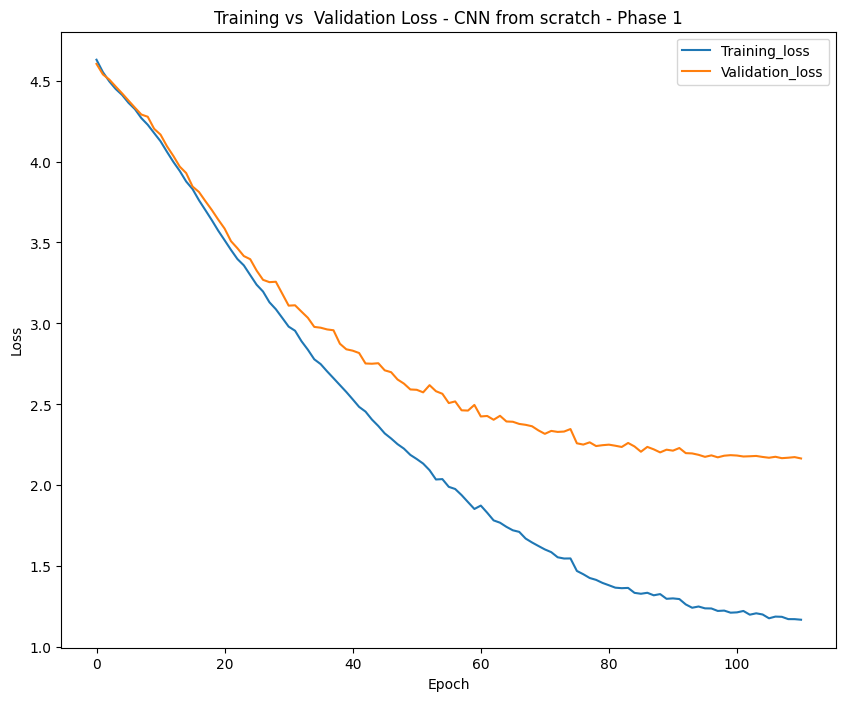

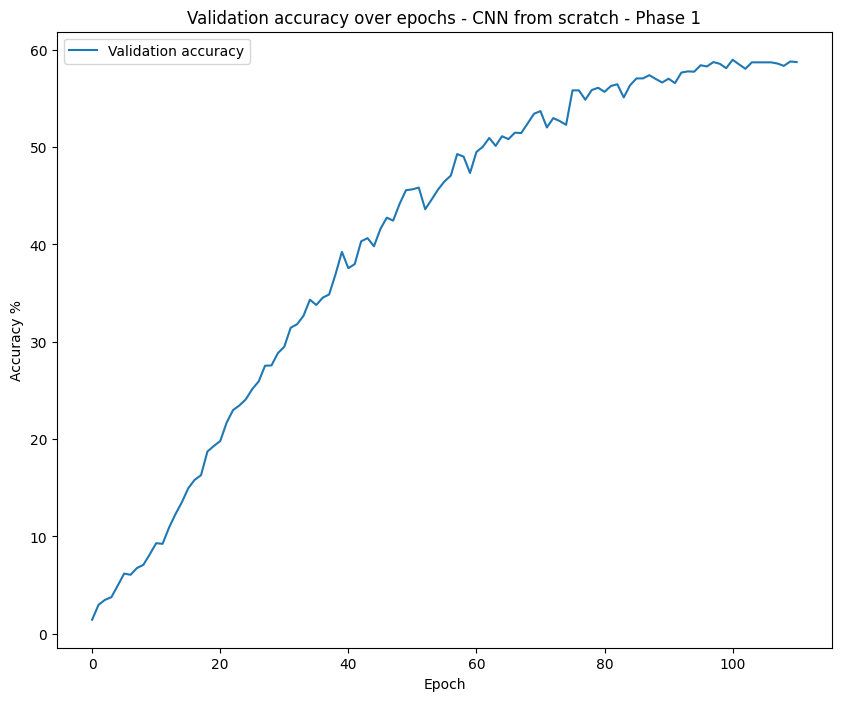

In [ ]:
history, best_val_acc = train_model(
    model=AircraftCNN(num_classes= 100),
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    checkpoint_path=cnn_checkpoint1,
    optimizer_type='adam',
    scheduler_type='ReduceLROnPlateau',
    num_epochs=150,
    early_stop_patience=10,
    mixup_alpha=0.0,
    title_suffix="- CNN from scratch - Phase 1"
)

Here we evaluate the trained model before, performance is consistent with observation on the validation split from training and evaluates to 58.51% on the test set

CNN Phase 1 Evaluation:
Test Loss : 2.1986
Test Acc  : 58.51%
----------------------------------------


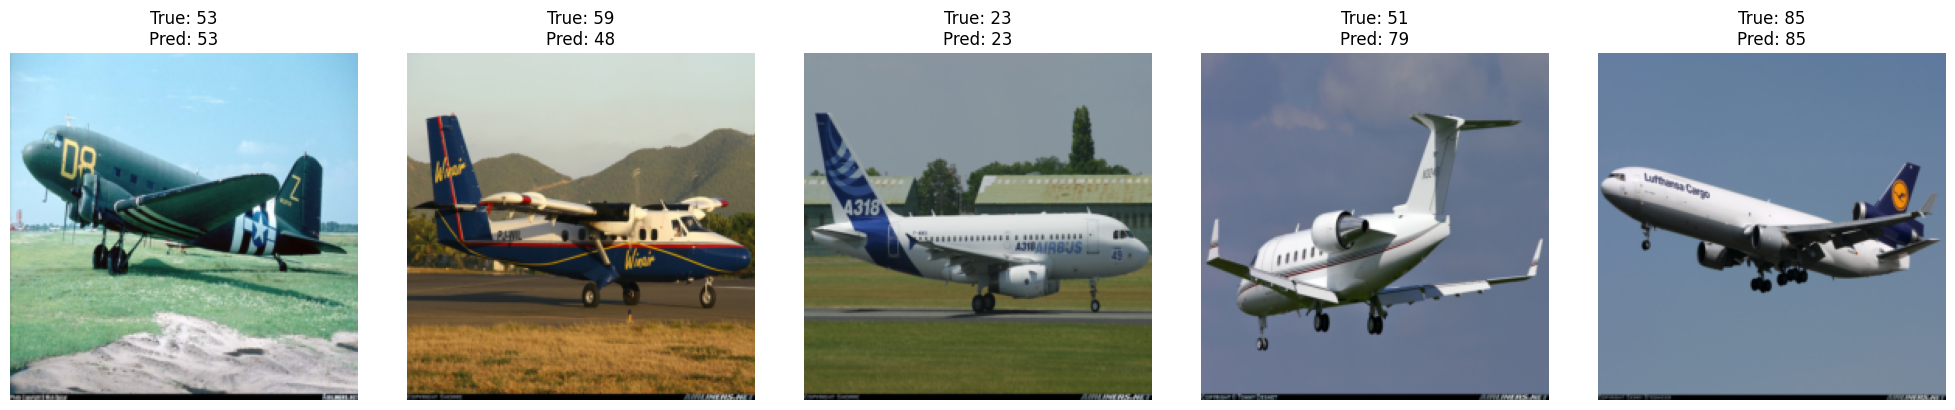

In [11]:
## Model
test_loss_cnn_phase1, test_acc_cnn_phase1 = evaluate_model(
    model_class=AircraftCNN,
    checkpoint_path=cnn_checkpoint1,
    test_loader=test_loader_cnn,
    test_dataset=test_dataset,
    model_type='cnn',
    verbose_name="CNN Phase 1",
    visualize=True,
    num_samples=5
)

## Ablation study

What follows is an ablation of the network. We check the perfomance of the network when a block is dropped, when the adaptive avg pooling is removed, when batch normalization is disabled, and how it behaves without dropout

In [12]:
class ManualCNN_ablation(AircraftCNN):
    def __init__(self, num_classes=100,ablation = None, input_size = 224):
      # ablation options
      # - remove block 4
      # - remove adaptive pool
      # - remove bn
      # - remove dropout
        super().__init__(num_classes)
        self.ablation = ablation

        if self.ablation == "remove block 4":
          self.conv4a = self.conv4b = self.bn4a = self.bn4b = nn.Identity()
        elif self.ablation == 'remove adaptive pool':
          self.adaptive_pool = nn.Identity()
          fc1_input_size = 512*14*14
          self.fc1 = nn.Linear(fc1_input_size,1024)
        elif self.ablation == "remove bn":
          self.bn1a = self.bn1b = nn.Identity()
          self.bn2a = self.bn2b = nn.Identity()
          self.bn3a = self.bn3b = nn.Identity()
          self.bn4a = self.bn4b = nn.Identity()
          self.bn_fc1 = nn.Identity()
          self.bn_fc2 = nn.Identity()
        elif self.ablation =='remove dropout':
          self.dropout_conv = nn.Idendity()
          self.dropout_fc = nn.Identity()
    def forward(self, x):
    # Block 1
      x = F.relu(self.bn1a(self.conv1a(x)))
      x = self.pool(F.relu(self.bn1b(self.conv1b(x))))
      if self.ablation != 'remove dropout':
         x = self.dropout_conv(x)

    # Block 2
      x = F.relu(self.bn2a(self.conv2a(x)))
      x = self.pool(F.relu(self.bn2b(self.conv2b(x))))
      if self.ablation != 'remove dropout':
         x = self.dropout_conv(x)

    # Block 3
      x = F.relu(self.bn3a(self.conv3a(x)))
      x = self.pool(F.relu(self.bn3b(self.conv3b(x))))

    # Block 4
      if self.ablation == "remove block 4":
        pass
      else:
        x = F.relu(self.bn4a(self.conv4a(x)))
        x = self.pool(F.relu(self.bn4b(self.conv4b(x))))
        if self.ablation != 'remove dropout':
          x = self.dropout_conv(x)

    # Adaptive Pooling
      x = self.adaptive_pool(x)

    # Flatten
      x = x.view(x.shape[0], -1)

    # FC layers — IDENTICO ad AircraftCNN quando ablation=None
      x = F.relu(self.bn_fc1(self.fc1(x)))    # ← AGGIUNGI bn_fc1!
      x = self.dropout_fc(x)
      x = F.relu(self.bn_fc2(self.fc2(x)))    # ← AGGIUNGI bn_fc2!
    # ← RIMUOVI dropout dopo fc2!
      x = self.fc3(x)
      return x

In [13]:
def train_model_fx(model, model_name="cnn_model"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4,weight_decay = 1e-4,decoupled_weight_decay=True)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    # Checkpoint path
    checkpoint_path = os.path.join(cnn_weights_folder, f"{model_name}.pt")

    # Initialize training variables
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0
    no_improve_epochs = 0
    start_epoch = 0
    num_epochs = 150
    early_stop_patience = 10

    # --- Resume from checkpoint if exists ---
    if os.path.exists(checkpoint_path):
        print(f"Found checkpoint for {model_name}, resuming training...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        history = checkpoint['history']
        best_val_acc = checkpoint.get('val_acc', 0)
        start_epoch = checkpoint['epoch']
        print(f"Resuming from epoch {start_epoch}, best_val_acc={best_val_acc:.2f}%")

    # --- Training loop ---
    for epoch in range(start_epoch, num_epochs):
        model.train()
        running_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = outputs.argmax(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Scheduler
        scheduler.step(val_acc)

        # Checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve_epochs = 0
            torch.save({
                'epoch': epoch+1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'history': history
            }, checkpoint_path)
            print(f"New best model saved at {checkpoint_path}")
        else:
            no_improve_epochs += 1

        # Early stopping
        if no_improve_epochs >= early_stop_patience:
            print(f"No improvement for {early_stop_patience} epochs. Early stopping.")
            break

    print(f"Training finished. Best val accuracy: {best_val_acc:.2f}%")
    print("Checkpoint saved at:", checkpoint_path)

    plot_training_history(history, title_suffix=f"- {model_name}")
    return history, checkpoint_path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
#Defining list to store all the study results
ablation_results_list = []


# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Initialize model ---
baseline_model = ManualCNN_ablation(num_classes=100)
baseline_model.to(device)

# --- Load checkpoint ---
checkpoint = torch.load(cnn_checkpoint1, map_location=device)
baseline_model.load_state_dict(checkpoint['model_state_dict'])

# --- Evaluate on test set ---
test_loss, test_acc = evaluate_testdata(baseline_model, test_loader_cnn, label_smoothing=0.1)

# --- Store results ---
baseline_results = {'name': 'Baseline', 'loss': test_loss, 'accuracy': test_acc}

ablation_results_list.append(baseline_results)

Evaluation -> Loss: 2.1986, Accuracy: 58.51%


### ABLATION 1

Remove block 4

Using device: cuda
Found checkpoint for cnn_ablation1, resuming training...
Resuming from epoch 69, best_val_acc=39.33%
Epoch 70/150 | Train Loss: 2.5512 | Val Loss: 2.6595 | Val Acc: 41.13%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation1.pt
Epoch 71/150 | Train Loss: 2.5239 | Val Loss: 2.6540 | Val Acc: 41.37%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation1.pt
Epoch 72/150 | Train Loss: 2.5191 | Val Loss: 2.6567 | Val Acc: 41.55%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation1.pt
Epoch 73/150 | Train Loss: 2.5104 | Val Loss: 2.6268 | Val Acc: 42.72%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation1.pt
Epoch 74/150 | Train Loss: 2.5138 | Val Loss: 2.6436 | Val Acc: 41.91%
Epoch 75/150 | Train Loss: 2.5115 | Val Loss: 2.6331 | Val Acc: 41.16%
Epoch 76/150 | Train Loss: 2.4538 | Val Loss: 2.6086 | Val

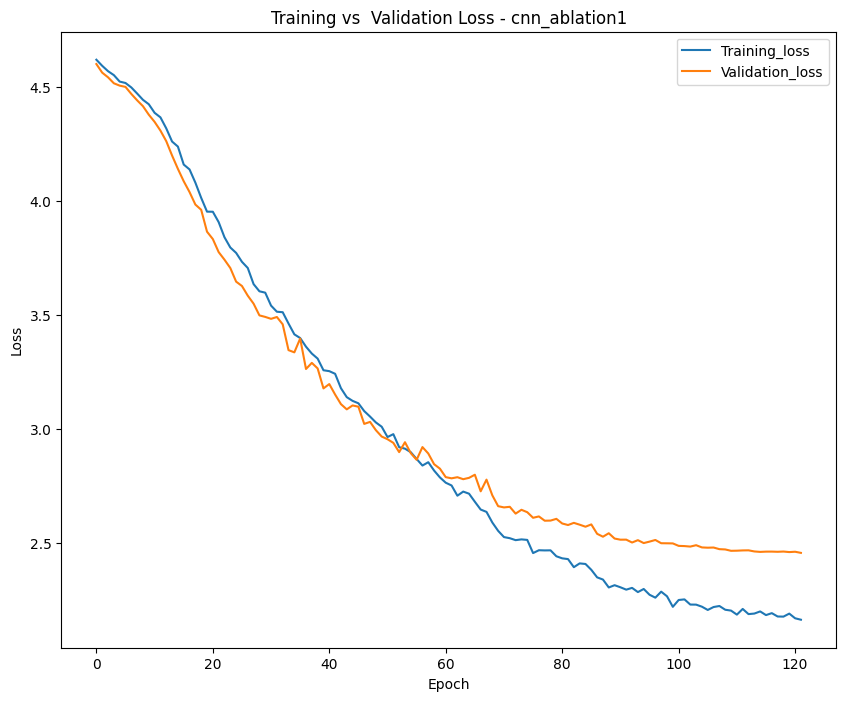

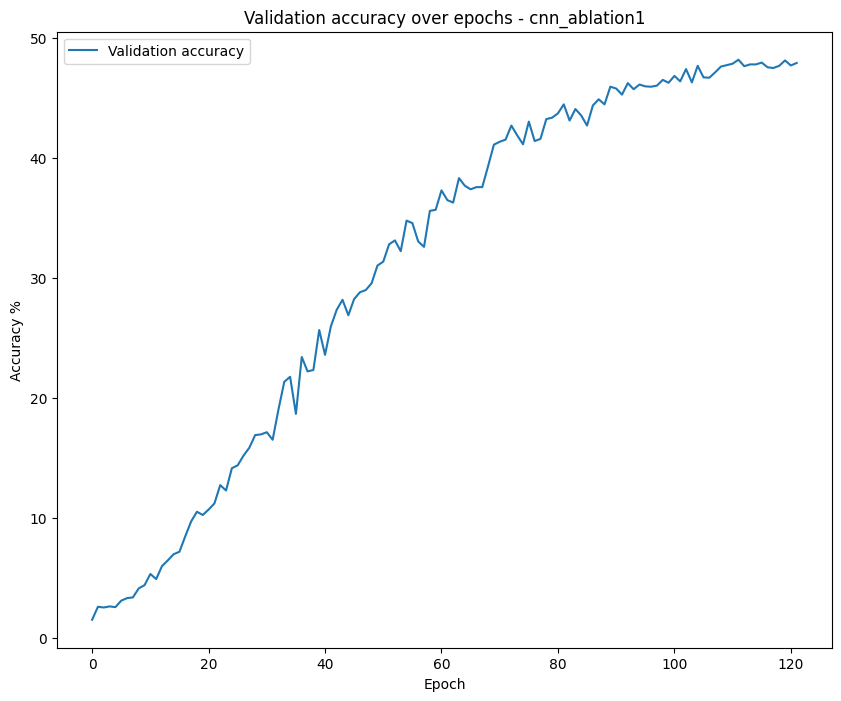

Evaluation -> Loss: 2.4777, Accuracy: 49.29%


In [ ]:
# --- Initialize Ablation 1 model ---
ablation1_model = ManualCNN_ablation(num_classes=100, ablation="remove_block4")

# --- Train the model ---
history_ablation1, checkpoint_ablation1 = train_model_fx(
    ablation1_model, model_name="cnn_ablation1"
)

# --- Load best checkpoint and evaluate ---
checkpoint = torch.load(checkpoint_ablation1, map_location=device)
ablation1_model.load_state_dict(checkpoint['model_state_dict'])

loss1, acc1 = evaluate_testdata(ablation1_model, test_loader_cnn, label_smoothing=0.1)

# --- Store results ---
ablation1_results = {'name': 'Ablation 1: Remove Block 4', 'loss': loss1, 'accuracy': acc1}
ablation_results_list.append(ablation1_results)

### ABLATION 2
Remove adaptive pool

Using device: cuda
Epoch 1/150 | Train Loss: 4.6254 | Val Loss: 4.5946 | Val Acc: 1.68%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation2.pt
Epoch 2/150 | Train Loss: 4.5996 | Val Loss: 4.5714 | Val Acc: 1.89%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation2.pt
Epoch 3/150 | Train Loss: 4.5777 | Val Loss: 4.5505 | Val Acc: 1.86%
Epoch 4/150 | Train Loss: 4.5674 | Val Loss: 4.5368 | Val Acc: 2.19%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation2.pt
Epoch 5/150 | Train Loss: 4.5529 | Val Loss: 4.5241 | Val Acc: 2.64%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation2.pt
Epoch 6/150 | Train Loss: 4.5348 | Val Loss: 4.4988 | Val Acc: 2.31%
Epoch 7/150 | Train Loss: 4.5014 | Val Loss: 4.4869 | Val Acc: 2.52%
Epoch 8/150 | Train Loss: 4.4811 | Val Loss: 4.4498 | Val Acc: 3.15%
New best model saved at /content/

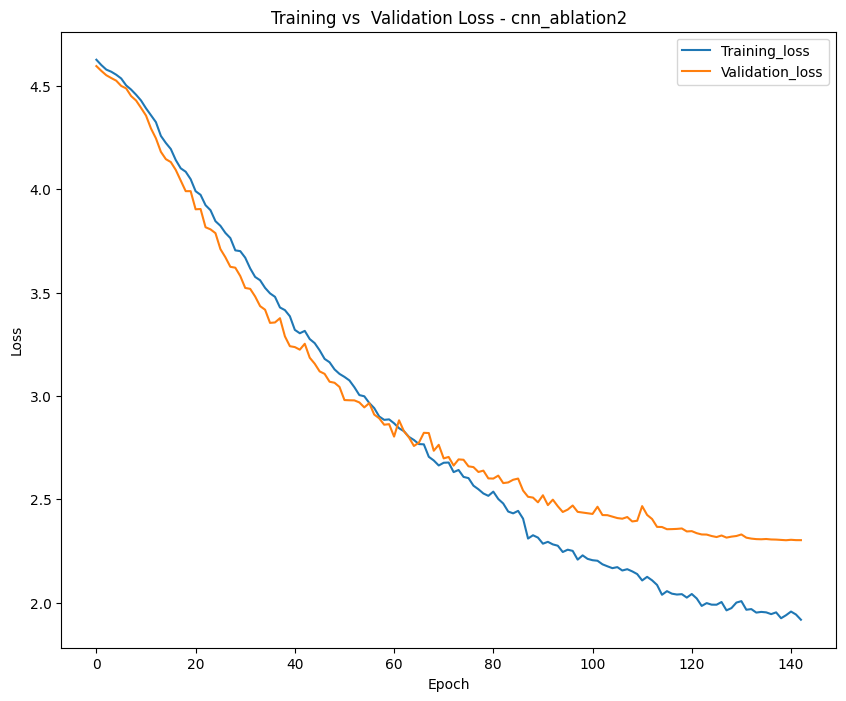

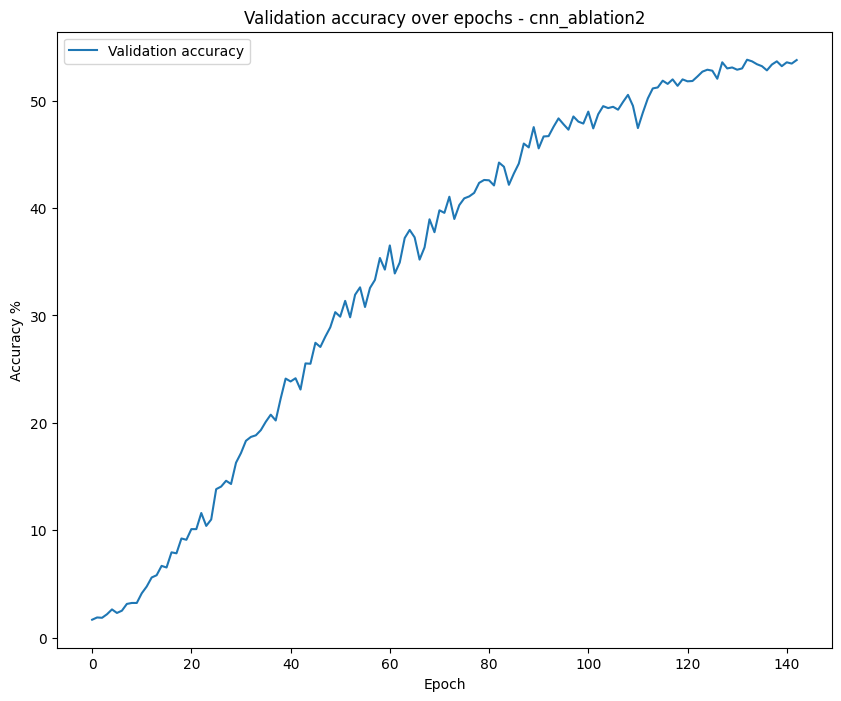

Evaluation -> Loss: 2.3108, Accuracy: 53.50%


In [ ]:
# --- Initialize Ablation 2 model ---
ablation2_model = ManualCNN_ablation(num_classes=100,  ablation="remove_adaptive_pool")

# --- Train the model ---
history_ablation2, checkpoint_ablation2 = train_model_fx(
    ablation2_model, model_name="cnn_ablation2"
)

# --- Load best checkpoint and evaluate ---
checkpoint = torch.load(checkpoint_ablation2, map_location=device)
ablation2_model.load_state_dict(checkpoint['model_state_dict'])

loss2, acc2 = evaluate_testdata(ablation2_model, test_loader_cnn, label_smoothing=0.1)

# --- Store results ---
ablation2_results = {'name': 'Ablation 2: Remove Adaptive Pool', 'loss': loss2, 'accuracy': acc2}
ablation_results_list.append(ablation2_results)


### ABLATION 3
Remove batchnorm

Using device: cuda
Found checkpoint for cnn_ablation3, resuming training...
Resuming from epoch 36, best_val_acc=22.26%
Epoch 37/150 | Train Loss: 3.3757 | Val Loss: 3.3170 | Val Acc: 21.36%
Epoch 38/150 | Train Loss: 3.3316 | Val Loss: 3.2869 | Val Acc: 22.65%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation3.pt
Epoch 39/150 | Train Loss: 3.2946 | Val Loss: 3.2371 | Val Acc: 23.25%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation3.pt
Epoch 40/150 | Train Loss: 3.2696 | Val Loss: 3.2421 | Val Acc: 24.30%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation3.pt
Epoch 41/150 | Train Loss: 3.2490 | Val Loss: 3.2006 | Val Acc: 25.20%
New best model saved at /content/drive/MyDrive/Aircaft classification/checkpoints/cnn_ablation3.pt
Epoch 42/150 | Train Loss: 3.2068 | Val Loss: 3.1703 | Val Acc: 25.68%
New best model saved at /content/drive/MyDrive/Aircaft cla

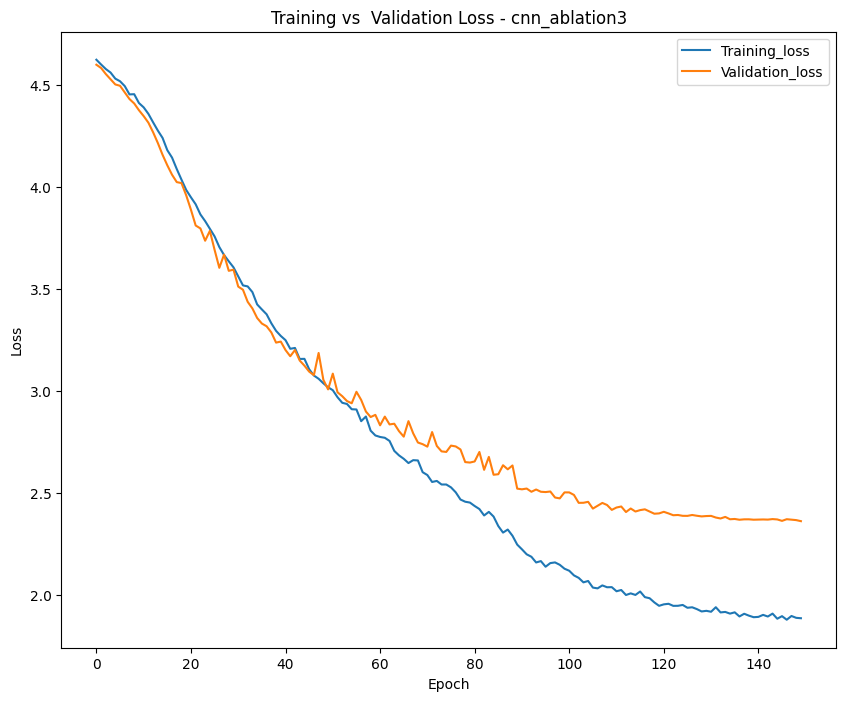

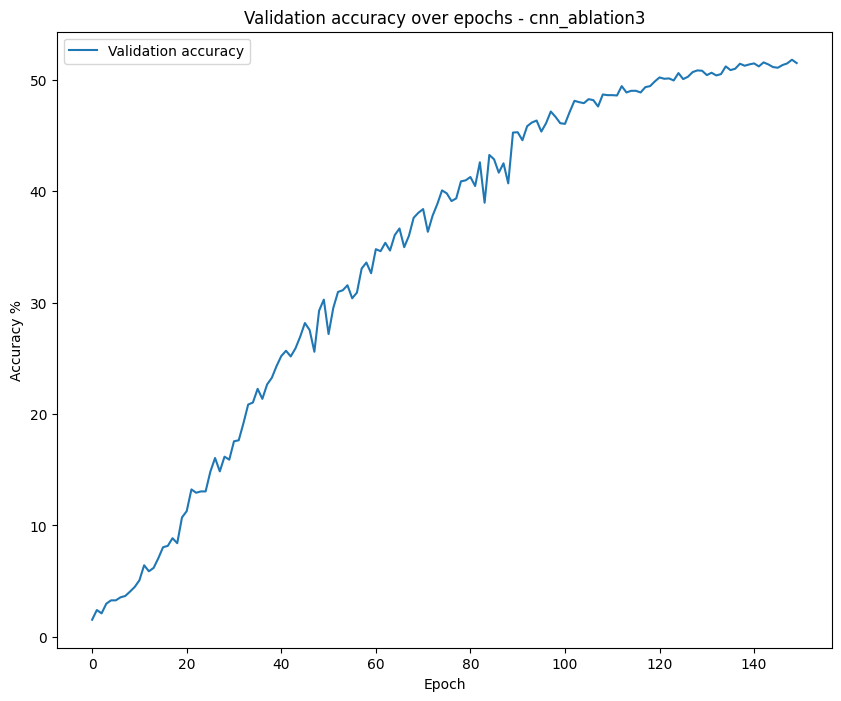

Evaluation -> Loss: 2.3695, Accuracy: 52.66%


In [ ]:
# --- Initialize Ablation 3 model ---
ablation3_model = ManualCNN_ablation(num_classes=100, ablation="remove_batchnorm")

# --- Train the model ---
history_ablation3, checkpoint_ablation3 = train_model_fx(
    ablation3_model, model_name="cnn_ablation3"
)

# --- Load best checkpoint and evaluate ---
checkpoint = torch.load(checkpoint_ablation3, map_location=device)
ablation3_model.load_state_dict(checkpoint['model_state_dict'])

loss3, acc3 = evaluate_testdata(ablation3_model, test_loader_cnn, label_smoothing=0.1)

# --- Store results ---
ablation3_results = {'name': 'Ablation 3: Remove Batchnorm', 'loss': loss3, 'accuracy': acc3}
ablation_results_list.append(ablation3_results)

###  ABLATION 4
Remove dropout



Using device: cuda
Found checkpoint for cnn_ablation4, resuming training...
Resuming from epoch 111, best_val_acc=55.84%
Epoch 112/150 | Train Loss: 1.3809 | Val Loss: 2.2377 | Val Acc: 55.27%
Epoch 113/150 | Train Loss: 1.3742 | Val Loss: 2.2381 | Val Acc: 55.06%
Epoch 114/150 | Train Loss: 1.3865 | Val Loss: 2.2370 | Val Acc: 55.30%
Epoch 115/150 | Train Loss: 1.3833 | Val Loss: 2.2366 | Val Acc: 55.27%
Epoch 116/150 | Train Loss: 1.3781 | Val Loss: 2.2355 | Val Acc: 55.00%
Epoch 117/150 | Train Loss: 1.3805 | Val Loss: 2.2414 | Val Acc: 54.91%
Epoch 118/150 | Train Loss: 1.3695 | Val Loss: 2.2401 | Val Acc: 55.21%
Epoch 119/150 | Train Loss: 1.3764 | Val Loss: 2.2416 | Val Acc: 54.79%
Epoch 120/150 | Train Loss: 1.3569 | Val Loss: 2.2452 | Val Acc: 54.85%
Epoch 121/150 | Train Loss: 1.3644 | Val Loss: 2.2368 | Val Acc: 55.18%
No improvement for 10 epochs. Early stopping.
Training finished. Best val accuracy: 55.84%
Checkpoint saved at: /content/drive/MyDrive/Aircaft classification/c

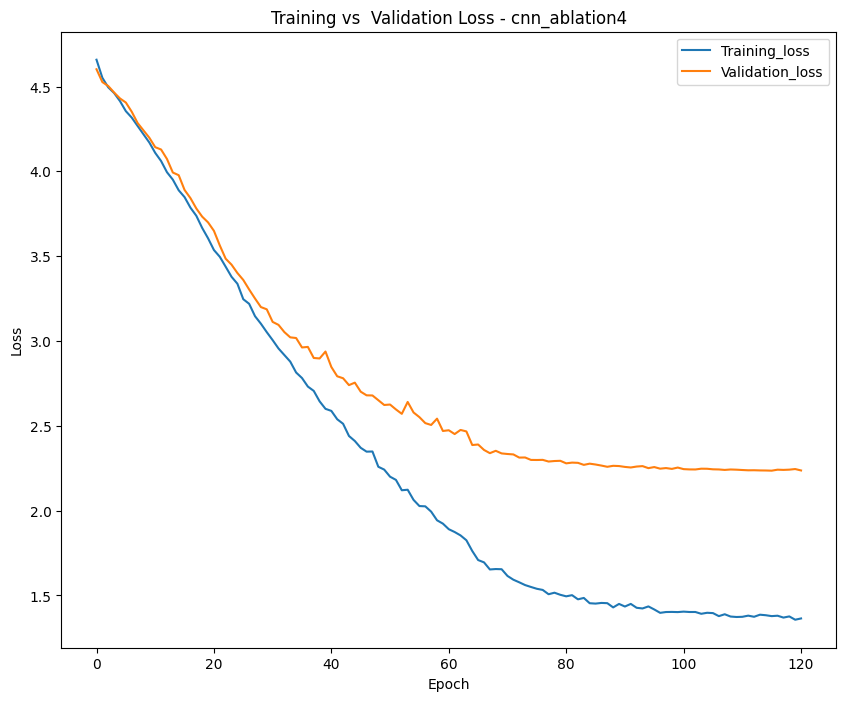

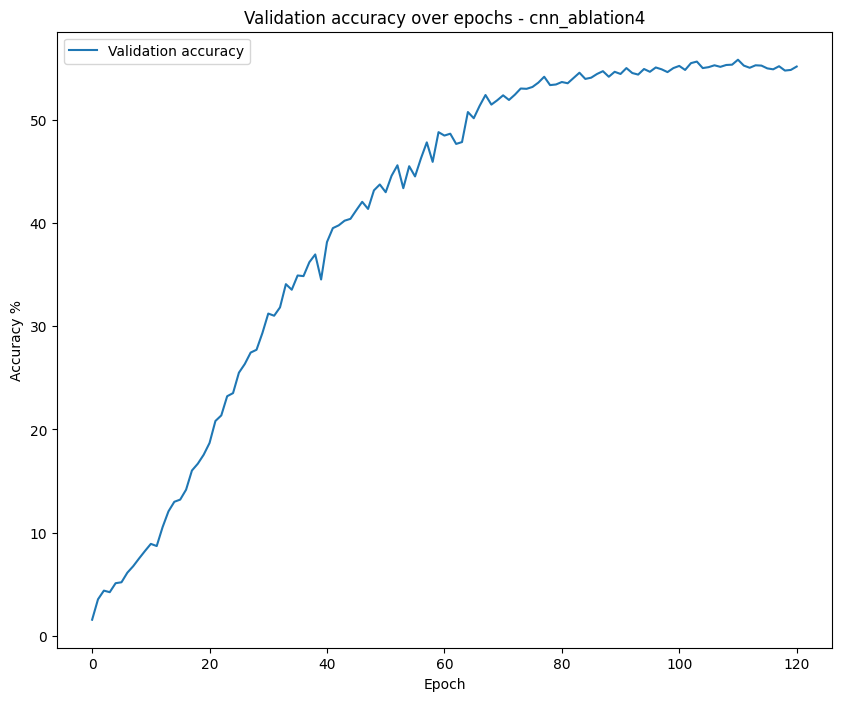

Evaluation -> Loss: 2.2675, Accuracy: 54.82%


In [ ]:
# --- Initialize Ablation 1 model ---
ablation4_model = ManualCNN_ablation(num_classes=100, ablation="remove_dropout")

# --- Train the model ---
history_ablation4, checkpoint_ablation4 = train_model_fx(
    ablation4_model, model_name="cnn_ablation4"
)

# --- Load best checkpoint and evaluate ---
checkpoint = torch.load(checkpoint_ablation4, map_location=device)
ablation4_model.load_state_dict(checkpoint['model_state_dict'])

loss4, acc4 = evaluate_testdata(ablation4_model, test_loader_cnn, label_smoothing=0.1)

# --- Store results ---
ablation4_results = {'name': 'Ablation 4: Remove Dropout', 'loss': loss4, 'accuracy': acc4}
ablation_results_list.append(ablation4_results)

### Conclusion of the ablation study

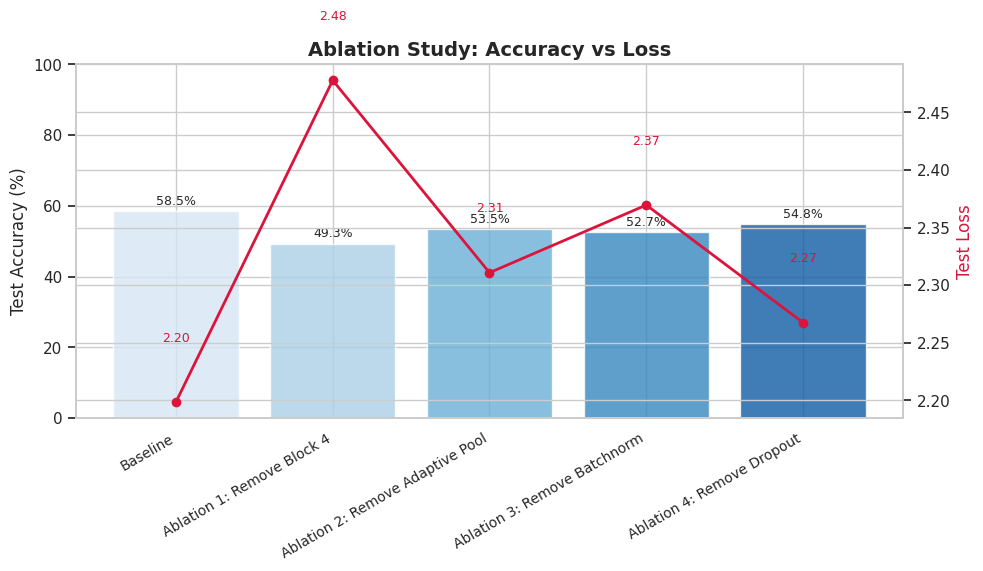

In [17]:
sns.set(style="whitegrid")

# Extract data
experiment_names = [d['name'] for d in ablation_results_list]
accuracies = [d['accuracy'] for d in ablation_results_list]
losses = [d['loss'] for d in ablation_results_list]

# Colors
bar_colors = sns.color_palette("Blues", len(accuracies))

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar chart for accuracy
bars = ax1.bar(experiment_names, accuracies, color=bar_colors, alpha=0.8)
ax1.set_ylabel("Test Accuracy (%)", fontsize=12)
ax1.set_ylim(0, 100)
ax1.set_xticks(range(len(experiment_names)))
ax1.set_xticklabels(experiment_names, rotation=30, ha='right', fontsize=10)

# Annotate accuracy bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontsize=9)

# Line plot for loss on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(experiment_names, losses, color='crimson', marker='o', linewidth=2, label='Test Loss')
ax2.set_ylabel("Test Loss", color='crimson', fontsize=12)

# Annotate loss points
for i, loss in enumerate(losses):
    ax2.text(i, loss + 0.05, f"{loss:.2f}", color='crimson', ha='center', va='bottom', fontsize=9)

plt.title("Ablation Study: Accuracy vs Loss", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


Our baseline 4-block CNN achieves the best performance (~58.51% test accuracy), and the ablation study demonstrates why each component is essential:

1.  Remove Block 4 (512 channels) -> 49.3%
Removing this block significantly reduces the network's depth and its capacity to learn high-level abstractions. The network loses the ability to represent the complex visual patterns necessary for fine-grained aircraft classification, proving that deeper layers are critical for discriminative feature extraction.
2.  Remove Adaptive Pooling -> 53.5%
Without adaptive pooling, the spatial dimensions of the feature map are no longer fixed to a standard size before the classifier. This leads an increase in the number of parameters in the subsequent fully connected layers, which drastically increases the risk of overfitting and hinders the model's ability to generalize across varying input dimensions.
3. Remove Batch Normalization -> 52.7%
Training becomes more unstable without normalization as witnessed by a more spiky loss curve. The network suffers from internal covariate shift, making gradients prone to exploding or vanishing, which severely hampers convergence. This confirms that BatchNorm is vital for stabilizing deep CNN training and allowing efficient optimization.
4. Remove Dropout -> 54.8%
   Without dropout, the network lacks explicit regularization during training. While training accuracy may rise, test accuracy drops because the model memorizes the training set rather than learning generalizable features. This highlights that regularization is crucial for preventing overfitting, even on moderately sized datasets.

Overall Conclusion:

The ablation study clearly validates each architectural choice: depth, spatial normalization, training stability, regularization, and classifier capacity all contribute to optimal learning and generalization. The full 4-block CNN successfully balances these elements, achieving the highest test accuracy.

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `FGVCAircraft`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~70%.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_classes = 100
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

resnet18 = resnet18.to(device)
resnet_checkpoint1 = Path(drive_checkpoint_dir) / "resnet_checkpoint1.pt"
resnet_checkpoint2 = Path(drive_checkpoint_dir) / "resnet_checkpoint2.pt"


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


### Part 2A - Training with the hyperparameters of part 1

Using device: cuda
Epoch 1: New best model saved with Val Acc = 16.83%
Epoch 1 | Train Loss 4.4405 | Train Acc 6.96% | Val Loss 3.9284 | Val Acc 16.83%
Epoch 2: New best model saved with Val Acc = 28.95%
Epoch 2 | Train Loss 3.5697 | Train Acc 30.05% | Val Loss 3.3586 | Val Acc 28.95%
Epoch 3: New best model saved with Val Acc = 41.04%
Epoch 3 | Train Loss 2.9416 | Train Acc 48.11% | Val Loss 2.8845 | Val Acc 41.04%
Epoch 4: New best model saved with Val Acc = 49.41%
Epoch 4 | Train Loss 2.4781 | Train Acc 63.62% | Val Loss 2.6449 | Val Acc 49.41%
Epoch 5: New best model saved with Val Acc = 53.68%
Epoch 5 | Train Loss 2.1108 | Train Acc 72.74% | Val Loss 2.4012 | Val Acc 53.68%
Epoch 6: New best model saved with Val Acc = 58.06%
Epoch 6 | Train Loss 1.8304 | Train Acc 80.98% | Val Loss 2.2512 | Val Acc 58.06%
Epoch 7: New best model saved with Val Acc = 59.26%
Epoch 7 | Train Loss 1.5787 | Train Acc 87.13% | Val Loss 2.1848 | Val Acc 59.26%
Epoch 8: New best model saved with Val Acc =

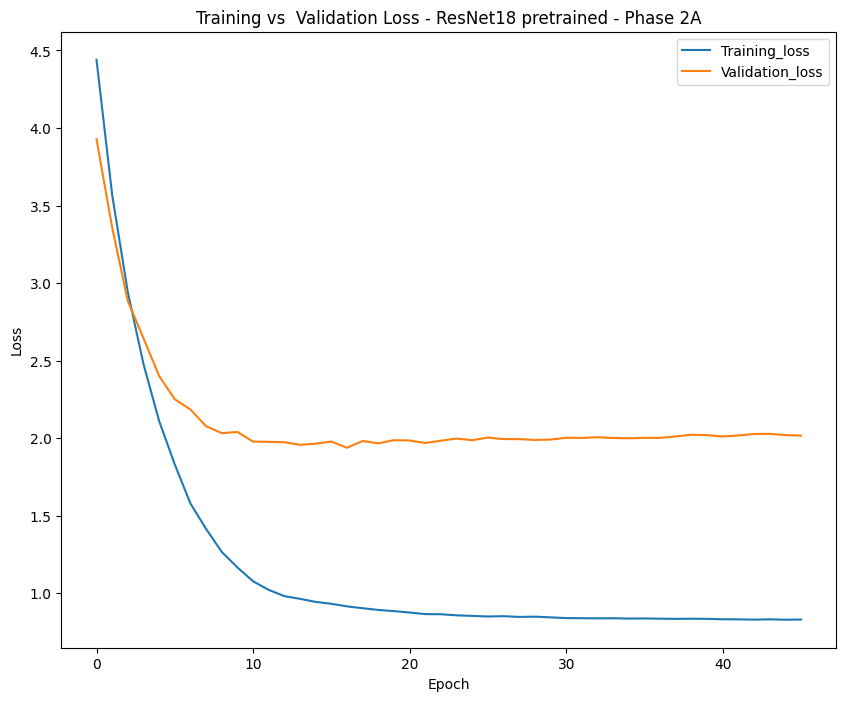

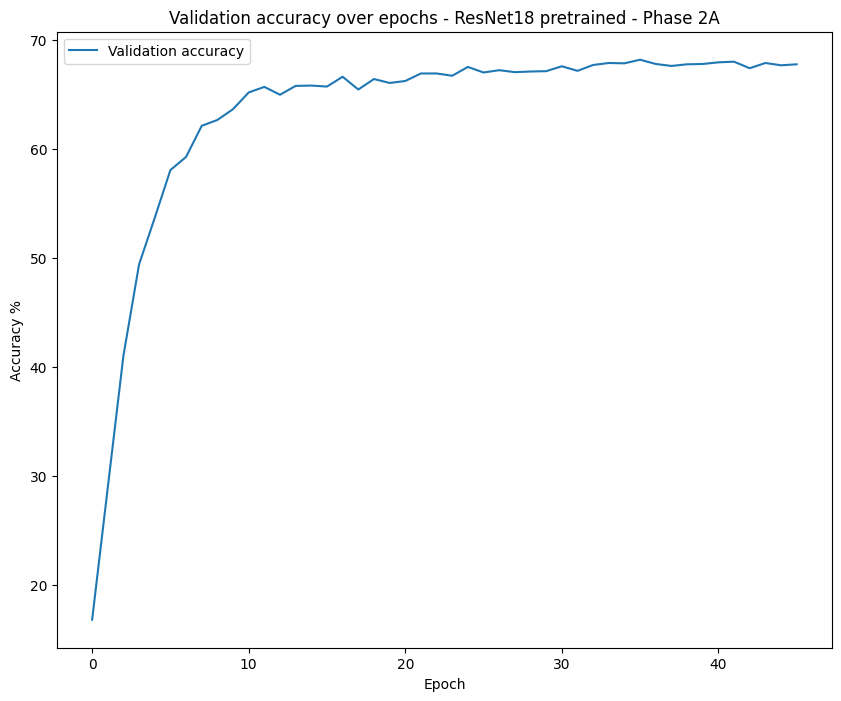

In [ ]:

history,best_val_acc = train_model(
    model=resnet18,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    checkpoint_path=resnet_checkpoint1,
    optimizer_type='adam',
    scheduler_type='ReduceLROnPlateau',
    num_epochs=150,
    early_stop_patience=10,
    mixup_alpha=0.0,
    title_suffix="- ResNet18 pretrained - Phase 2A"
)

#### Analysis of 2A

ResNet18 Phase 2A Evaluation:
Test Loss : 1.9897
Test Acc  : 68.83%
----------------------------------------


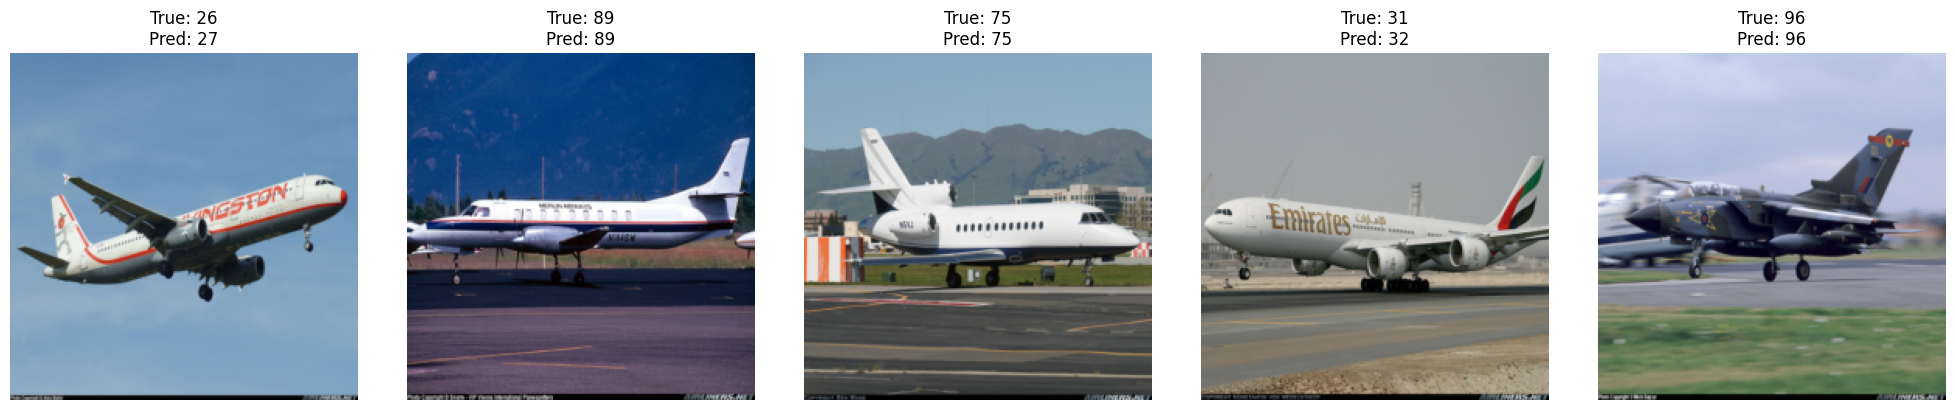

In [ ]:
test_loader_resnet = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)
test_loss_resnet_phase2A, test_acc_resnet_phase2A = evaluate_model(
    checkpoint_path=resnet_checkpoint1,
    test_loader=test_loader_resnet,
    test_dataset=test_dataset,
    model_type='resnet',
    verbose_name="ResNet18 Phase 2A",
    visualize=True,
    num_samples=5
)

Observations from training:

* Training accuracy reached near perfection (99.97% at epoch 46)
* Validation accuracy plateaued early and remained low (Best: 68.17%, Final: 67.75%)
* Large divergence between training loss (0.8308) and validation loss (2.0166)
* Test performance aligns closely with validation (Test Acc: 68.83%, Test Loss: 1.9897)
* Early stopping triggered at epoch 46 after 10 epochs without improvement.

Reasons for the overfitting:

* Insufficient Regularization: While label smoothing and basic augmentations were applied, they were insufficient to prevent the model from memorizing the training set. The lack of advanced regularization (like mixup, CutMix, or dropout) allowed the gap to widen to \~32%.
* Dataset Size vs. Model Capacity: ResNet18 has sufficient capacity to perfectly memorize a moderate dataset (\~7k images). Instead of learning generalized breed features, it resorted to memorizing training examples.
* Fine-tuning Strategy: Unrestricted fine-tuning of the backbone on a small dataset likely destroyed the pretrained general features too quickly, replacing them with dataset-specific memorizations.

Conclusion:
Phase 2A ResNet18 suffers from overfitting. The current regularization strategy is insufficient for this dataset size and should therefore be the aim of further improvements by applying more advanced regularization techniques or shifting to a more aggressive learning rate schedule.





### Part 2B - Changing the hyperparameters to improve accuracy

Using device: cuda
Epoch 1: New best model saved with Val Acc = 67.60%
Epoch 1 | Train Loss 1.6179 | Train Acc 49.34% | Val Loss 2.0364 | Val Acc 67.60%
Epoch 2: New best model saved with Val Acc = 67.78%
Epoch 2 | Train Loss 1.7774 | Train Acc 54.89% | Val Loss 2.0284 | Val Acc 67.78%
Epoch 3 | Train Loss 1.7170 | Train Acc 38.15% | Val Loss 2.0521 | Val Acc 67.18%
Epoch 4 | Train Loss 1.5266 | Train Acc 48.29% | Val Loss 2.0357 | Val Acc 67.78%
Epoch 5 | Train Loss 1.4475 | Train Acc 38.87% | Val Loss 2.0335 | Val Acc 67.78%
Epoch 6 | Train Loss 1.5564 | Train Acc 50.90% | Val Loss 2.0383 | Val Acc 67.66%
Epoch 7: New best model saved with Val Acc = 67.81%
Epoch 7 | Train Loss 1.5690 | Train Acc 50.51% | Val Loss 2.0388 | Val Acc 67.81%
Epoch 8 | Train Loss 1.6584 | Train Acc 44.03% | Val Loss 2.0481 | Val Acc 67.42%
Epoch 9 | Train Loss 1.4776 | Train Acc 40.97% | Val Loss 2.0374 | Val Acc 67.36%
Epoch 10 | Train Loss 1.7461 | Train Acc 50.06% | Val Loss 2.0638 | Val Acc 67.09%
Epoc

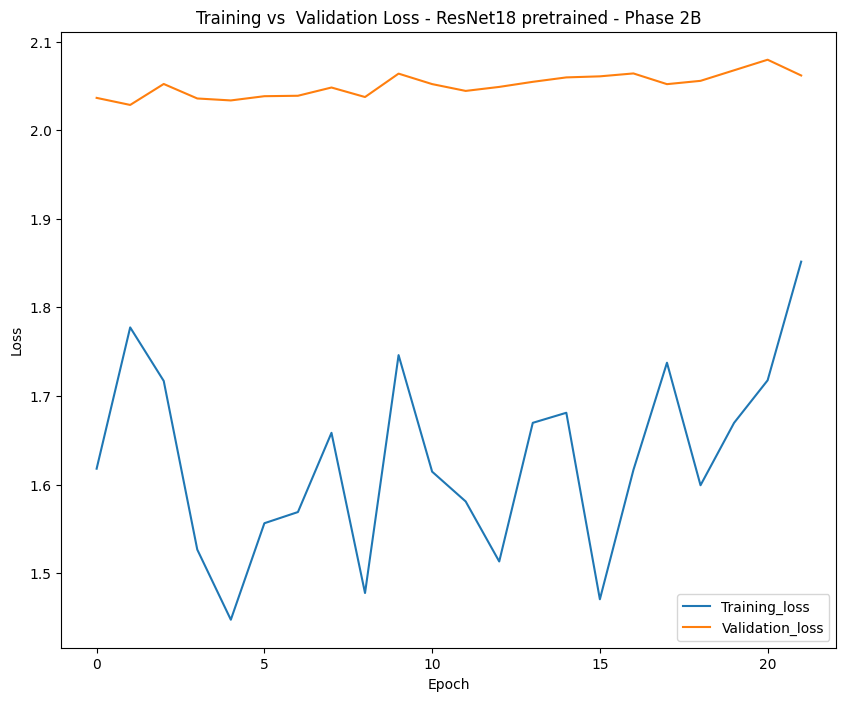

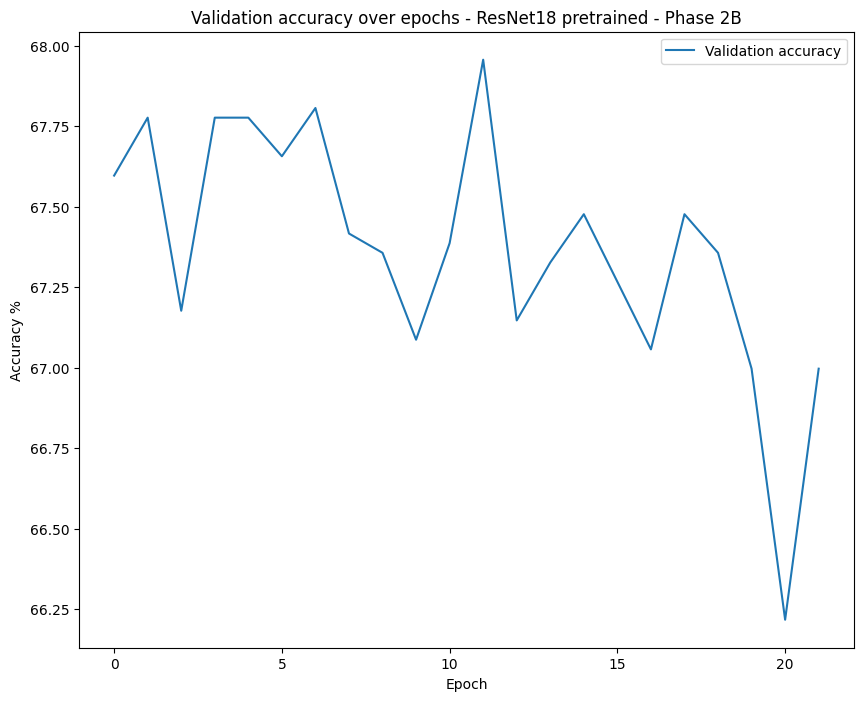

In [ ]:

history, best_val_acc = train_model(
    model=resnet18,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    checkpoint_path=resnet_checkpoint2,
    optimizer_type='sgd',
    scheduler_type='OneCycleLR',
    lr_backbone=3e-4,
    lr_head=3e-3,
    num_epochs=150,
    early_stop_patience=10,
    mixup_alpha=0.3,
    steps_per_epoch=math.ceil(len(train_loader)),
    title_suffix="- ResNet18 pretrained - Phase 2B"
)


#### Analysis of 2B

### Evaluation on test split

ResNet18 Phase 2B Evaluation:
Test Loss : 1.9451
Test Acc  : 69.16%
----------------------------------------


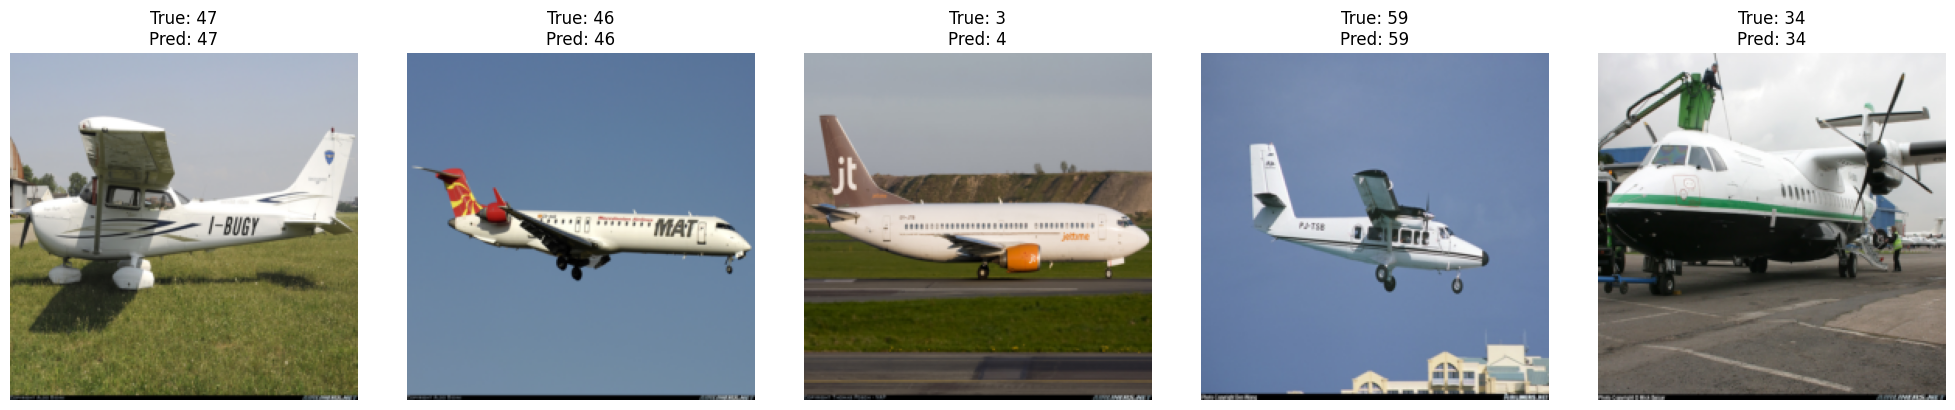

In [ ]:
test_loss_resnet_phase2B, test_acc_resnet_phase2B = evaluate_model(
    checkpoint_path=resnet_checkpoint2,
    test_loader=test_loader_resnet,
    test_dataset=test_dataset,
    model_type='resnet',
    label_smoothing=0.08,
    verbose_name="ResNet18 Phase 2B",
    visualize=True,
    num_samples=5
)


Strategies implemented to fix Phase 2A overfitting:
Added Mixup regularization (alpha=0.3) to smooth decision boundaries and prevent memorization.
Implemented discriminative learning rates (Backbone: 3e-4, Head: 3e-3) to preserve pretrained features while allowing the classifier to adapt faster.
Switched to OneCycleLR scheduler for better convergence dynamics.
Test Accuracy: 69.16% (a marginal +0.33% improvement over Phase 2A's 68.83%)
Test Loss: 1.9451 (a slight improvement over Phase 2A's 1.9897).

Reasons for the marginal improvement:

1.   Inherent Difficulty of FGVC Aircraft: The FGVC Aircraft dataset is a notoriously challenging fine-grained classification task. Distinguishing between visually similar aircraft variants (e.g., Boeing 737-700 vs. 737-800) requires capturing extremely subtle features. Even with Mixup and discriminative learning rates, the model struggles to isolate these minute differences with limited data (\~7.4k images).
2.  Insufficient Regularization Impact: While Mixup is a powerful technique, an alpha of 0.3 was not enough to fully bridge the massive generalization gap observed in Phase 2A (\~32% gap between train and val). The model continues to struggle with the highly specific, fine-grained features required for the validation/test sets.
3. Loss Remains High: A test loss of \~1.94 indicates the model is still highly uncertain or overconfident on incorrect predictions. Mixup often increases training loss by design (making the task harder), but the test loss should decrease more significantly if generalization is truly improving. The minimal drop suggests the model hasn't escaped its prior suboptimal feature representation.

Phase 2B applied the correct theoretical fixes—discriminative learning rates and Mixup—to address the severe overfitting seen in Phase 2A. However, the empirical results show only a marginal improvement (69.16% vs 68.83%). The fine-grained nature of the FGVC Aircraft dataset makes it highly resistant to general improvements; the model requires highly specific feature discrimination. The chosen regularization strength was insufficient to overcome the dataset's complexity. Further significant improvement would likely require more aggressive augmentation pipelines (e.g., CutMix combined with Mixup), freezing more of the initial backbone layers to force the head to learn better discriminative features, or moving to a higher-capacity model.